[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# Bending of a two incompressible cantilevers rigidly linked at the free end

Last updated: 07/15/26

## Problem description

Two parallel cantilevers are rigidly linked at the free end.
They bend in sync due to the rigid link.

Displacements and bending moments are provided in the reference.

## References

This is the AFNOR SSLL05/89 test case.

Original source: "Guide de validation des progiciels de calcul de structures"
publié par l'AFNOR 1990 (ISBN 2-12-486611-7).

Data taken from: ICAB Force Exemples Exemples de calculs de statique pour ICAB
Force. www.icab.fr

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [1]:
import context
from pystran import model
from pystran import section
from pystran import plots
import numpy

In [2]:
E = 200e9
A = 1.0
I = 4 / 3 * 10**-8
sb = section.beam_2d_section("sb", E=E, A=A, I=I)

In [3]:
h = 2
F = 1.0e3

The rigid link formulation requires a penalty for each degree of freedom.
This penalty needs to be of appropriate magnitude, commensurate with the
other stiffnesses in the system. This particular formulation does not require
the penalty to be many times larger, just in the ballpark. Here we take a
fraction of the `E*A`  product.


In [4]:
sr = section.rigid_link_section("sr", Gamma=E*A/10 * numpy.diagflat([1.0, 1.0, 1.0]))

In [5]:
m = model.create(2)
freedoms = m["freedoms"]

In [6]:
model.add_joint(m, 1, (0.0, 0.0))
model.add_joint(m, 2, (h, 0.0))
model.add_joint(m, 3, (0.0, -0.2))
model.add_joint(m, 4, (h, -0.2))

{'jid': 4, 'coordinates': array([ 2. , -0.2])}

Here are the two beam members.


In [7]:
model.add_beam_member(m, 1, (1, 2), sb)
model.add_beam_member(m, 2, (3, 4), sb)


{'mid': 2,
 'connectivity': (3, 4),
 'section': {'name': 'sb',
  'E': 200000000000.0,
  'rho': 0.0,
  'CTE': 0.0,
  'A': 1.0,
  'I': 1.3333333333333334e-08}}

The free ends are linked together rigidly.


In [8]:
model.add_rigid_link_member(m, 1, (2, 4), sr)

{'mid': 1,
 'connectivity': (2, 4),
 'section': {'name': 'sr',
  'Gamma': array([[2.e+10, 0.e+00, 0.e+00],
         [0.e+00, 2.e+10, 0.e+00],
         [0.e+00, 0.e+00, 2.e+10]])}}

The rigid link is shown with a slightly thicker line.


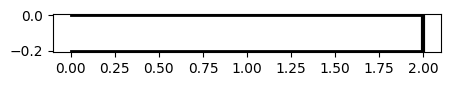

In [9]:
plots.setup(m)
plots.plot_members(m)
plots.show(m)

In [10]:
model.add_support(m["joints"][1], freedoms.ALL_DOFS)
model.add_support(m["joints"][3], freedoms.ALL_DOFS)
model.add_load(m["joints"][4], freedoms.U2, -F)

The transverse force is applied to only one of the bars.


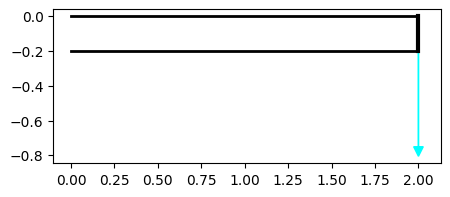

In [11]:
plots.setup(m)
plots.plot_members(m)
plots.plot_applied_forces(m)
plots.show(m)

Solve the system. 


In [12]:
model.number_dofs(m)
model.solve_statics(m)

Using the stiffness coefficients of a beam in the basic configuration, we
can calculate the deflection from the relationship between the shear force
in the beams (there are two!) and the applied force, assuming 
the bars are nearly incompressible in the axial direction.

In [13]:
w2 = F / (12 * E * I / h**3) / 2
print("Analytical deflection in the direction of the force: ", w2)
print("Expected tip deflection: ", [0.0, -1.25250329e-01, 0])
for j in m["joints"].values():
    print(j["displacements"])

Analytical deflection in the direction of the force:  0.125
Expected tip deflection:  [0.0, -0.125250329, 0]
[0. 0. 0.]
[ 4.99997650e-08 -1.25001750e-01 -1.74999178e-06]
[0. 0. 0.]
[-4.99997650e-08 -1.25001775e-01 -1.77499166e-06]


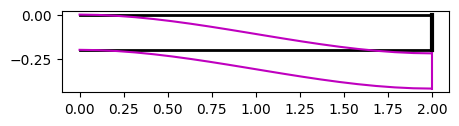

In [14]:
plots.setup(m)
plots.plot_members(m)
plots.plot_deformations(m)
plots.show(m)

Again using the basic stiffness, we deduce the correct magnitude of the bending moment:


Analytical bending moment magnitude:  500.0


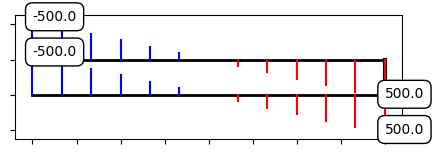

In [15]:
M = 6 * h * E * I / h**3 * w2
print("Analytical bending moment magnitude: ", M)
plots.setup(m)
plots.plot_members(m)
plots.plot_bending_moments(m)
plots.show(m)

## Conclusions

The rigid link is approximated with a penalty method. We can see that the analytical results are approximated rather well.